
# Fashion Image Classification using CNN

## Objective

The objective of this project is to build a Convolutional Neural Network
(CNN) to classify fashion images into different clothing categories.

## Dataset

The Fashion-MNIST dataset contains 70,000 grayscale images of clothing
items belonging to 10 different categories. Each image has a resolution
of 28 × 28 pixels.

## Project Workflow

- Dataset loading
- Exploratory Data Analysis
- Image preprocessing
- Baseline CNN
- Improved CNN
- Data augmentation
- Model training
- Model evaluation
- Confusion matrix analysis
- Misclassified image analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Dataset Loading

The Fashion-MNIST dataset is loaded directly using TensorFlow/Keras.

The dataset contains 60,000 training images and 10,000 test images.
Each image is a 28 × 28 grayscale image.

In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 2. Understanding the Classes

Fashion-MNIST contains 10 different categories of clothing and footwear.
Each numerical label corresponds to one of these categories.

In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Dataset Overview

Before building the CNN, we examine the dimensions of the dataset
and the distribution of the target classes.

In [6]:
print("Number of training samples:", len(X_train))
print("Number of test samples:", len(X_test))
print("Image dimensions:", X_train.shape[1:])
print("Number of classes:", len(class_names))

Number of training samples: 60000
Number of test samples: 10000
Image dimensions: (28, 28)
Number of classes: 10


## 4. Exploratory Data Analysis

### Sample Image Visualization

A sample of images from the training dataset is visualized to
understand the appearance of different fashion categories.

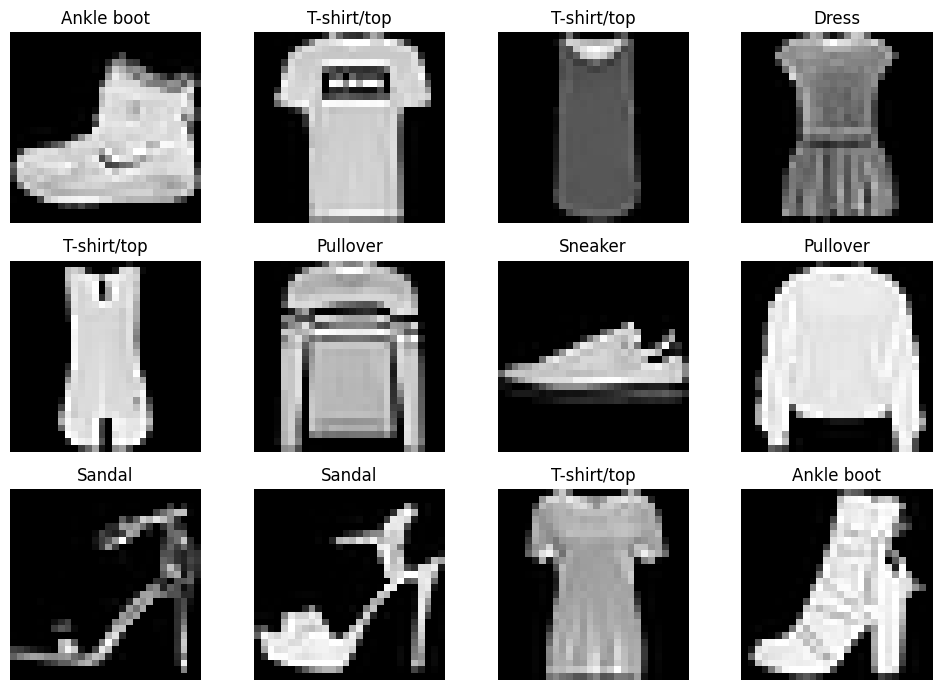

In [7]:
plt.figure(figsize=(10, 7))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Class Distribution

The distribution of the 10 fashion categories is examined to determine
whether the training dataset is reasonably balanced across classes.

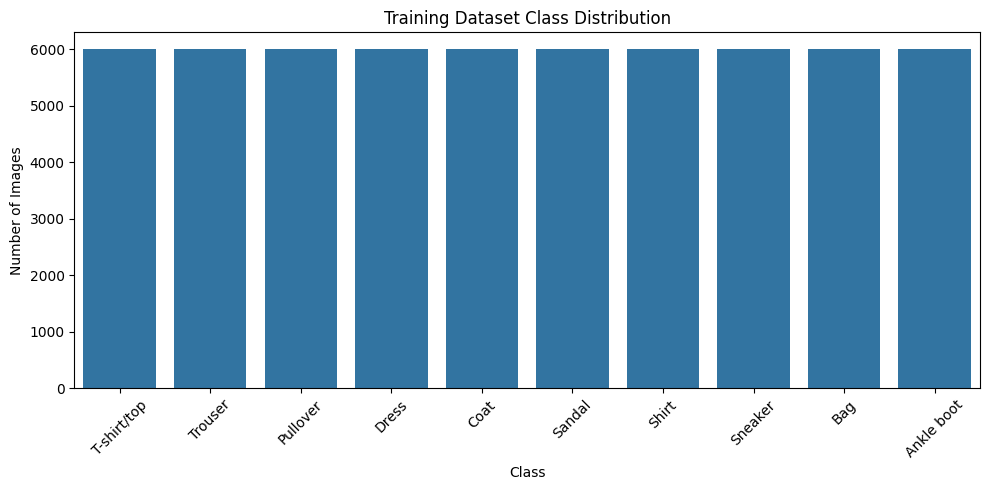

In [8]:
plt.figure(figsize=(10, 5))

sns.countplot(x=y_train)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(range(10), class_names, rotation=45)

plt.tight_layout()
plt.show()

### EDA Finding

The class distribution is approximately balanced, with around 6,000
images available for each of the 10 categories. Therefore, no major
class imbalance is observed in the training dataset.

## 5. Image Preprocessing

Before training the CNN, the image data needs to be preprocessed.

The pixel values originally range from 0 to 255. We normalize these
values to a range between 0 and 1 to make the training process more
stable and efficient.

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Reshaping Images for CNN

CNNs expect image data to contain a channel dimension. Since
Fashion-MNIST images are grayscale, each image has one channel.

In [10]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


## 6. Baseline CNN

A baseline Convolutional Neural Network (CNN) is developed as a
reference model before introducing additional techniques such as
data augmentation, batch normalization, and dropout.

The CNN consists of convolutional layers for extracting visual
features, pooling layers for reducing spatial dimensions, and
dense layers for final classification.

In [11]:
baseline_model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

The model is compiled using the Adam optimizer and sparse categorical
cross-entropy loss. Accuracy is used as the primary training metric.

In [12]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 7. Baseline Model Training

The baseline CNN is trained for a small number of epochs to establish
a reference performance for comparison with the improved model.

In [13]:
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 103ms/step - accuracy: 0.7893 - loss: 0.5913 - val_accuracy: 0.8422 - val_loss: 0.4315
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.8678 - loss: 0.3689 - val_accuracy: 0.8720 - val_loss: 0.3536
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.8832 - loss: 0.3250 - val_accuracy: 0.8792 - val_loss: 0.3424


## 8. Baseline Model Evaluation

The trained baseline CNN is evaluated on the unseen test dataset to
measure its generalization performance.

In [14]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline Test Loss:", round(baseline_loss, 4))
print("Baseline Test Accuracy:", round(baseline_accuracy, 4))

Baseline Test Loss: 0.3574
Baseline Test Accuracy: 0.8713


## 9. Data Augmentation

Data augmentation is used to create slightly modified versions of
training images. This helps the CNN learn more robust visual patterns
and can reduce overfitting.

The augmentation techniques used in this project include small
rotations, zooming, and translations.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


### Visualizing Data Augmentation

The effect of augmentation is visualized by applying random
transformations to a sample training image.

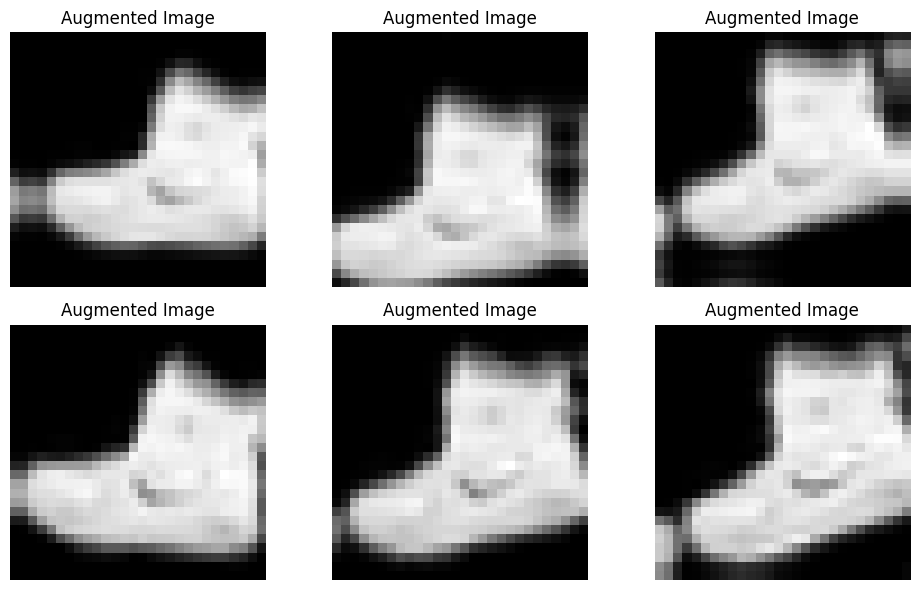

In [16]:
sample_image = X_train[0]

plt.figure(figsize=(10, 6))

for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Augmented Image")

plt.tight_layout()
plt.show()

## 10. Improved CNN Architecture

An improved CNN is developed by combining convolutional layers with
batch normalization and dropout.

Data augmentation is applied during training to improve generalization.
Batch normalization helps stabilize the learning process, while dropout
reduces the risk of overfitting.

In [17]:
model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Data augmentation
    data_augmentation,

    # First convolution block
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,802 (3.42 MB)

 Trainable params: 897,354 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

## 11. Compile the Improved CNN

The improved CNN is compiled using the Adam optimizer and sparse
categorical cross-entropy loss. Accuracy is used as the primary
evaluation metric.

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 12. Training the Improved CNN

The improved CNN is trained using the augmented training data.
A validation split is used to monitor the model's performance on
unseen validation images during training.

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 130s 301ms/step - accuracy: 0.7217 - loss: 0.7607 - val_accuracy: 0.6952 - val_loss: 0.7757
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 127s 301ms/step - accuracy: 0.7898 - loss: 0.5659 - val_accuracy: 0.8310 - val_loss: 0.4356
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 127s 302ms/step - accuracy: 0.8108 - loss: 0.5120 - val_accuracy: 0.8248 - val_loss: 0.4500
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 126s 297ms/step - accuracy: 0.8269 - loss: 0.4723 - val_accuracy: 0.8548 - val_loss: 0.3648
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 143s 301ms/step - accuracy: 0.8329 - loss: 0.4568 - val_accuracy: 0.8487 - val_loss: 0.4143


## 13. Improved CNN Evaluation

The improved CNN is evaluated on the unseen test dataset. Its
performance is compared with the baseline CNN to determine whether
the additional regularization and augmentation techniques improved
generalization.

In [20]:
improved_loss, improved_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Improved CNN Test Loss:", round(improved_loss, 4))
print("Improved CNN Test Accuracy:", round(improved_accuracy, 4))

Improved CNN Test Loss: 0.4281
Improved CNN Test Accuracy: 0.8434


## 14. Model Comparison

The baseline CNN achieved a test accuracy of 87.13%, while the improved
CNN achieved 84.34%.

Although the improved CNN introduced data augmentation, batch
normalization, and dropout, its test performance was lower than the
baseline model.

This indicates that increasing model complexity does not always lead
to better performance. The augmentation and regularization settings
may have been too aggressive for this relatively simple dataset.

The baseline CNN is therefore selected as the better-performing model
for this experiment.

## 15. Training History

The training and validation accuracy are visualized to understand how
the baseline CNN performed during training.

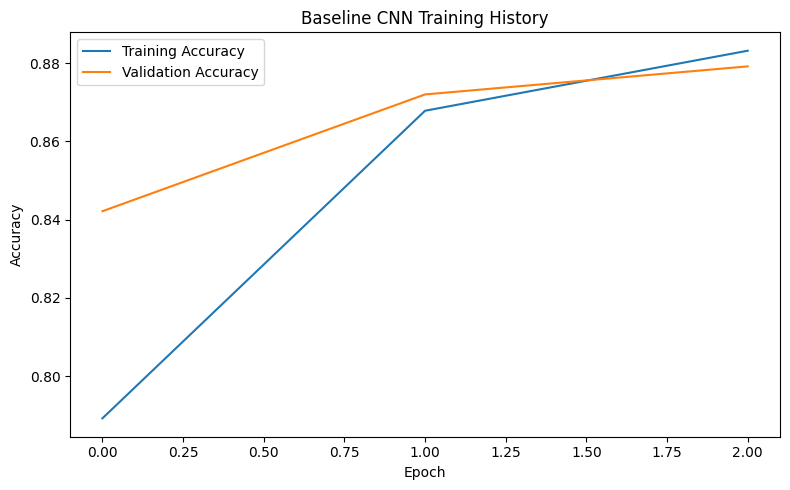

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline CNN Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Training History Findings

The training and validation accuracy both increased across the three
epochs. The relatively small gap between the training and validation
curves indicates that the baseline CNN did not show severe overfitting
during this training period.

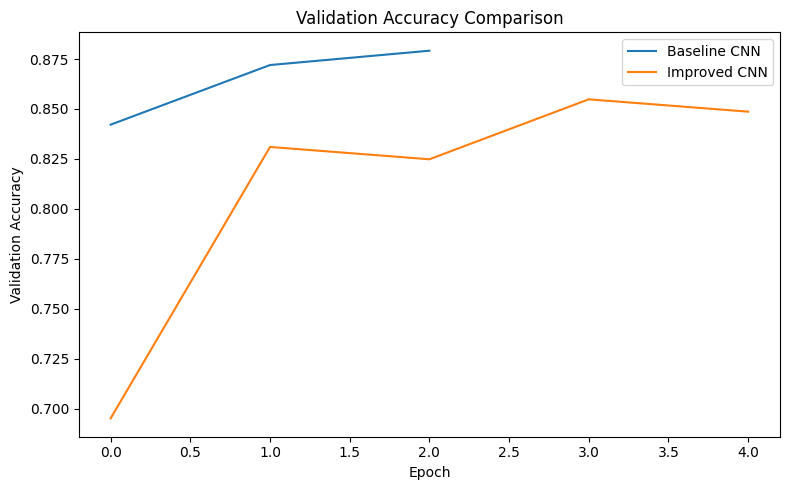

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Baseline CNN"
)

plt.plot(
    history.history["val_accuracy"],
    label="Improved CNN"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Validation Accuracy Comparison

The validation accuracy comparison shows that the baseline CNN achieved
higher validation accuracy throughout the training period.

The improved CNN reached approximately 85% validation accuracy, but it
did not outperform the baseline model. This supports the observation
that the additional augmentation and regularization techniques did not
improve performance under the current configuration.

## 16. Confusion Matrix

A confusion matrix is used to analyze the classification performance
of the baseline CNN across all 10 Fashion-MNIST classes.

It helps identify which categories are frequently confused by the model.

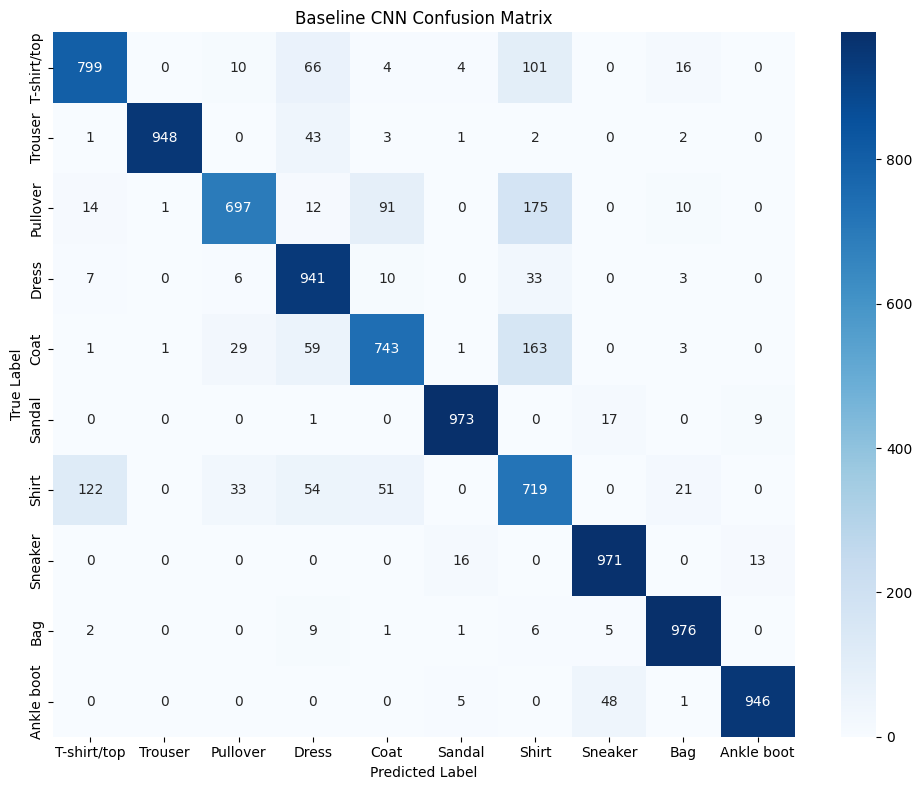

In [22]:
y_pred_probs = baseline_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Confusion Matrix Findings

The confusion matrix shows that the baseline CNN performs well on
visually distinctive classes such as Sandal, Sneaker, Bag, and
Ankle boot.

The model has more difficulty distinguishing visually similar
upper-body clothing categories. In particular, Shirt, T-shirt/top,
Coat, and Pullover are frequently confused with one another.

This suggests that these categories contain similar visual patterns,
making them more challenging for the CNN to classify correctly.

## 17. Classification Report

Precision, recall, and F1-score are calculated for each clothing
category to provide a more detailed evaluation than accuracy alone.

In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.80      0.82      1000
     Trouser       1.00      0.95      0.97      1000
    Pullover       0.90      0.70      0.79      1000
       Dress       0.79      0.94      0.86      1000
        Coat       0.82      0.74      0.78      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.60      0.72      0.65      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



### Classification Report Findings

The baseline CNN achieved an overall accuracy of approximately 87%.

The model performed particularly well on visually distinctive classes
such as Trouser, Sandal, Sneaker, Bag, and Ankle boot.

The Shirt class had the lowest F1-score at 0.65, indicating that it was
the most challenging category for the model. This is consistent with
the confusion matrix, where Shirt was frequently confused with
T-shirt/top, Coat, and Pullover.

Overall, the results show that the model performs well on distinctive
objects but has more difficulty separating visually similar clothing
categories.

## 18. Error Analysis: Misclassified Images

A sample of incorrectly classified test images is visualized to
understand the types of images that are difficult for the CNN.

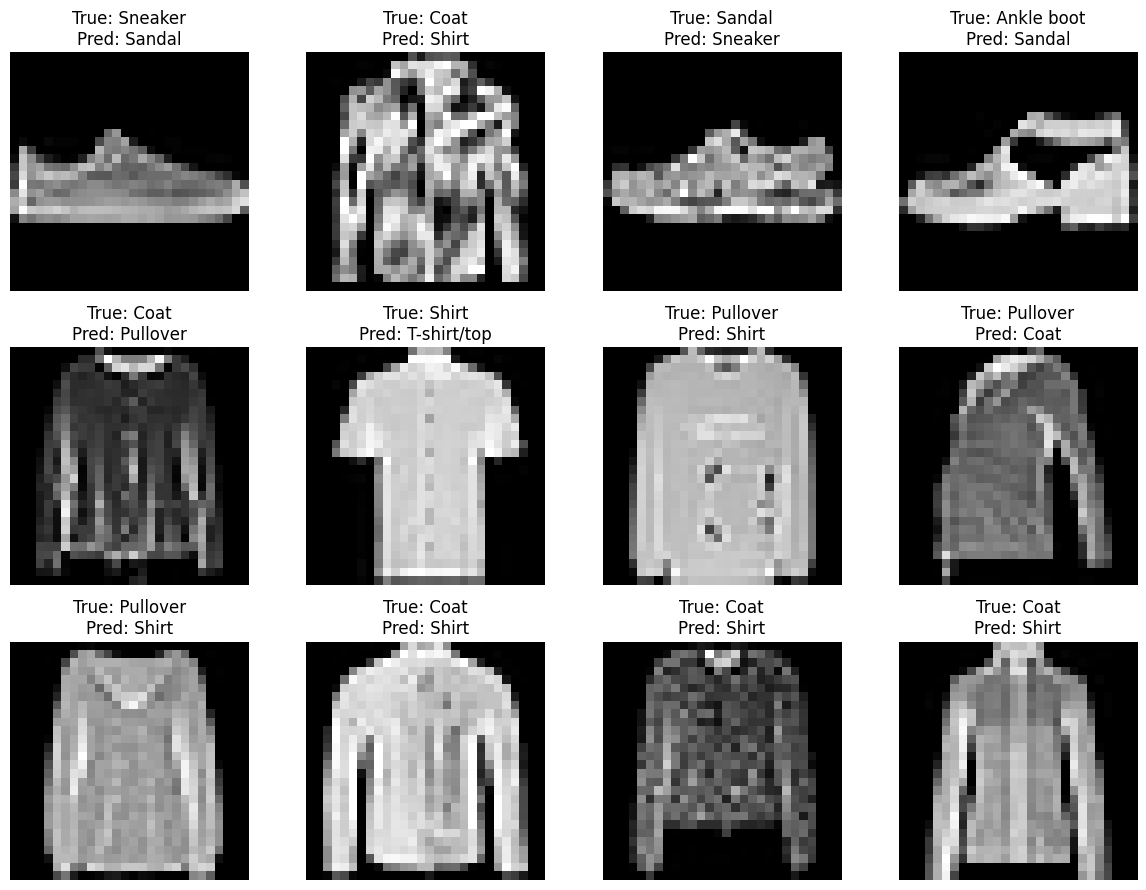

In [24]:
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 9))

for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[idx].squeeze(), cmap="gray")

    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Error Analysis Findings

The misclassified images confirm the patterns observed in the confusion
matrix. Several errors occur between visually similar upper-body
categories such as Coat, Pullover, Shirt, and T-shirt/top.

Because Fashion-MNIST images are low-resolution 28 × 28 grayscale images,
fine-grained clothing details can be difficult for the CNN to distinguish.

This analysis shows that model evaluation should go beyond overall
accuracy and include investigation of class-level errors.

## 19. Final Conclusion

A convolutional neural network was developed to classify images from
the Fashion-MNIST dataset.

The baseline CNN achieved a test accuracy of **87.13%**, providing the
best performance among the models evaluated in this project.

An improved CNN incorporating data augmentation, batch normalization,
and dropout was also developed. However, it achieved a lower test
accuracy of **84.34%**.

The comparison demonstrates that increasing model complexity does not
necessarily improve performance. The confusion matrix, classification
report, and misclassified-image analysis showed that the model performs
well on visually distinctive categories but has difficulty separating
similar upper-body clothing classes.

Overall, the project demonstrates an end-to-end deep learning workflow
including exploratory data analysis, preprocessing, CNN development,
model comparison, evaluation, and error analysis.

## 20. Future Improvements

Several improvements could be explored in future work:

- Hyperparameter tuning for learning rate, batch size, dropout rate,
  and CNN architecture.
- Experimenting with different data augmentation strengths.
- Using learning-rate scheduling and early stopping.
- Testing deeper CNN architectures.
- Exploring transfer learning with pretrained image models.
- Applying techniques such as Grad-CAM to improve model interpretability.
- Investigating more advanced architectures such as ResNet or EfficientNet.
- Performing systematic error analysis on the most frequently confused
  clothing categories.